# **EXP B - 01: NeuralLW offline**

## **0. Setup**

In [1]:
# Load packages
using Revise
using NeuralLongwave

┌ Warning: attempting to remove probably stale pidfile
│   path = C:\Users\stefa\.julia\compiled\v1.10\NeuralLongwave\wtrZE_AOHXo.ji.pidfile
└ @ FileWatching.Pidfile C:\Users\stefa\.julia\juliaup\julia-1.10.11+0.x64.w64.mingw32\share\julia\stdlib\v1.10\FileWatching\src\pidfile.jl:244


In [2]:
# Define experiments and general settings
EXP = "exp_B"
SER = "01_NLW_MLP_offline"

# Define units
BASELINES = ["0_OBLW"]
UNITS = ["$(f)_w$(lpad(w, 3, '0'))_h$(d)" for f in ("direct", "linear", "planck") for w in (32, 64, 128) for d in 1:3];

In [3]:
# Reference climate and noise floor (generated once, shared by all experiments)
noise = collect_rollouts("climate_noise", "01_OBLW", ["0_OBLW", "0_OBLW_pert"]; leg = :climate)
ref   = noise.var"0_OBLW"
floor = noise.var"0_OBLW_pert";

In [4]:
# Load all weather and climate rollouts and timings
w = collect_rollouts(EXP, SER, UNITS, leg = :weather)
c = collect_rollouts(EXP, SER, UNITS; leg = :climate)
t = load_timings(EXP, SER);

In [5]:
# Define looks
ms_base = 10
w1 = ms_base
w2 = 1.5*w1
w3 = 1.5*w2

looks = (;
    var"0_OBLW_pert" = (; label="OBLW pert.", color=:black),

    direct_w032_h1 = (; label="Direct H1", color=JL_BLUE,  marker=:circle, markersize=w1, group=:w32h1),
    direct_w032_h2 = (; label="Direct H2", color=JL_BLUE,  marker=:diamond, markersize=w1, group=:w32h2),
    direct_w032_h3 = (; label="Direct H3", color=JL_BLUE,  marker=:rect, markersize=w1, group=:w32h3),

    direct_w064_h1 = (; label="Direct H1", color=JL_BLUE,  marker=:circle, markersize=w2, group=:w64h1),
    direct_w064_h2 = (; label="Direct H2", color=JL_BLUE,  marker=:diamond, markersize=w2, group=:w64h2),
    direct_w064_h3 = (; label="Direct H3", color=JL_BLUE,  marker=:rect, markersize=w2, group=:w64h3),

    direct_w128_h1 = (; label="Direct H1", color=JL_BLUE,  marker=:circle, markersize=w3, group=:w128h1),
    direct_w128_h2 = (; label="Direct H2", color=JL_BLUE,  marker=:diamond, markersize=w3, group=:w128h2),
    direct_w128_h3 = (; label="Direct H3", color=JL_BLUE,  marker=:rect, markersize=w3, group=:w128h3),


    linear_w032_h1 = (; label="Linear H1", color=JL_GREEN,  marker=:circle, markersize=w1, group=:w32h1),
    linear_w032_h2 = (; label="Linear H2", color=JL_GREEN,  marker=:diamond, markersize=w1, group=:w32h2),
    linear_w032_h3 = (; label="Linear H3", color=JL_GREEN,  marker=:rect, markersize=w1, group=:w32h3),

    linear_w064_h1 = (; label="Linear H1", color=JL_GREEN,  marker=:circle, markersize=w2, group=:w64h1),
    linear_w064_h2 = (; label="Linear H2", color=JL_GREEN,  marker=:diamond, markersize=w2, group=:w64h2),
    linear_w064_h3 = (; label="Linear H3", color=JL_GREEN,  marker=:rect, markersize=w2, group=:w64h3),

    linear_w128_h1 = (; label="Linear H1", color=JL_GREEN,  marker=:circle, markersize=w3, group=:w128h1),
    linear_w128_h2 = (; label="Linear H2", color=JL_GREEN,  marker=:diamond, markersize=w3, group=:w128h2),
    linear_w128_h3 = (; label="Linear H3", color=JL_GREEN,  marker=:rect, markersize=w3, group=:w128h3),


    planck_w032_h1 = (; label="Planck H1", color=JL_RED,  marker=:circle, markersize=w1, group=:w32h1),
    planck_w032_h2 = (; label="Planck H2", color=JL_RED,  marker=:diamond, markersize=w1, group=:w32h2),
    planck_w032_h3 = (; label="Planck H3", color=JL_RED,  marker=:rect, markersize=w1, group=:w32h3),

    planck_w064_h1 = (; label="Planck H1", color=JL_RED,  marker=:circle, markersize=w2, group=:w64h1),
    planck_w064_h2 = (; label="Planck H2", color=JL_RED,  marker=:diamond, markersize=w2, group=:w64h2),
    planck_w064_h3 = (; label="Planck H3", color=JL_RED,  marker=:rect, markersize=w2, group=:w64h3),

    planck_w128_h1 = (; label="Planck H1", color=JL_RED,  marker=:circle, markersize=w3, group=:w128h1),
    planck_w128_h2 = (; label="Planck H2", color=JL_RED,  marker=:diamond, markersize=w3, group=:w128h2),
    planck_w128_h3 = (; label="Planck H3", color=JL_RED,  marker=:rect, markersize=w3, group=:w128h3),
);

## **1. Training**

In [17]:
summarize_series(EXP, SER; by = :loss_total, n_ep = 5, tol = 0.015)

Row,unit,loss_total,settled,converged,pct
,String,Float64,Int64,Bool,Float64
1,planck_w064_h2,0.000532439,55,true,0.0
2,linear_w128_h2,0.000544593,56,true,2.3
3,planck_w128_h3,0.00054803,56,true,2.9
4,planck_w128_h2,0.000556634,55,true,4.5
5,planck_w064_h3,0.000569397,55,true,6.9
6,linear_w064_h3,0.000575099,55,true,8.0
7,linear_w064_h2,0.000584327,55,true,9.7
8,linear_w128_h3,0.000604974,55,true,13.6
9,direct_w128_h2,0.000819384,55,true,53.9


## **2. Weather Cost Plane**

In [6]:
# Create tables
wt = weather_table(w)
ct = climate_table(c, ref, floor)
tt = timing_table(t);

In [7]:
# Test reference
test_reference((collect_rollouts(EXP, SER, BASELINES, leg=:weather)).var"0_OBLW")

┌ Info: Reference reproduced exactly for every probe and trajectory.
└ @ NeuralLongwave c:\Code\NeuralLongwave.jl\src\evaluation\rollout_weather.jl:86


Row,probe,max_error,n_exact,n_traj,failed_ics
,Symbol,Float64,Int64,Int64,Array…
1,T,0.0,52,52,Int64[]
2,olw,0.0,52,52,Int64[]
3,slwd,0.0,52,52,Int64[]


In [11]:
using NeuralLongwave

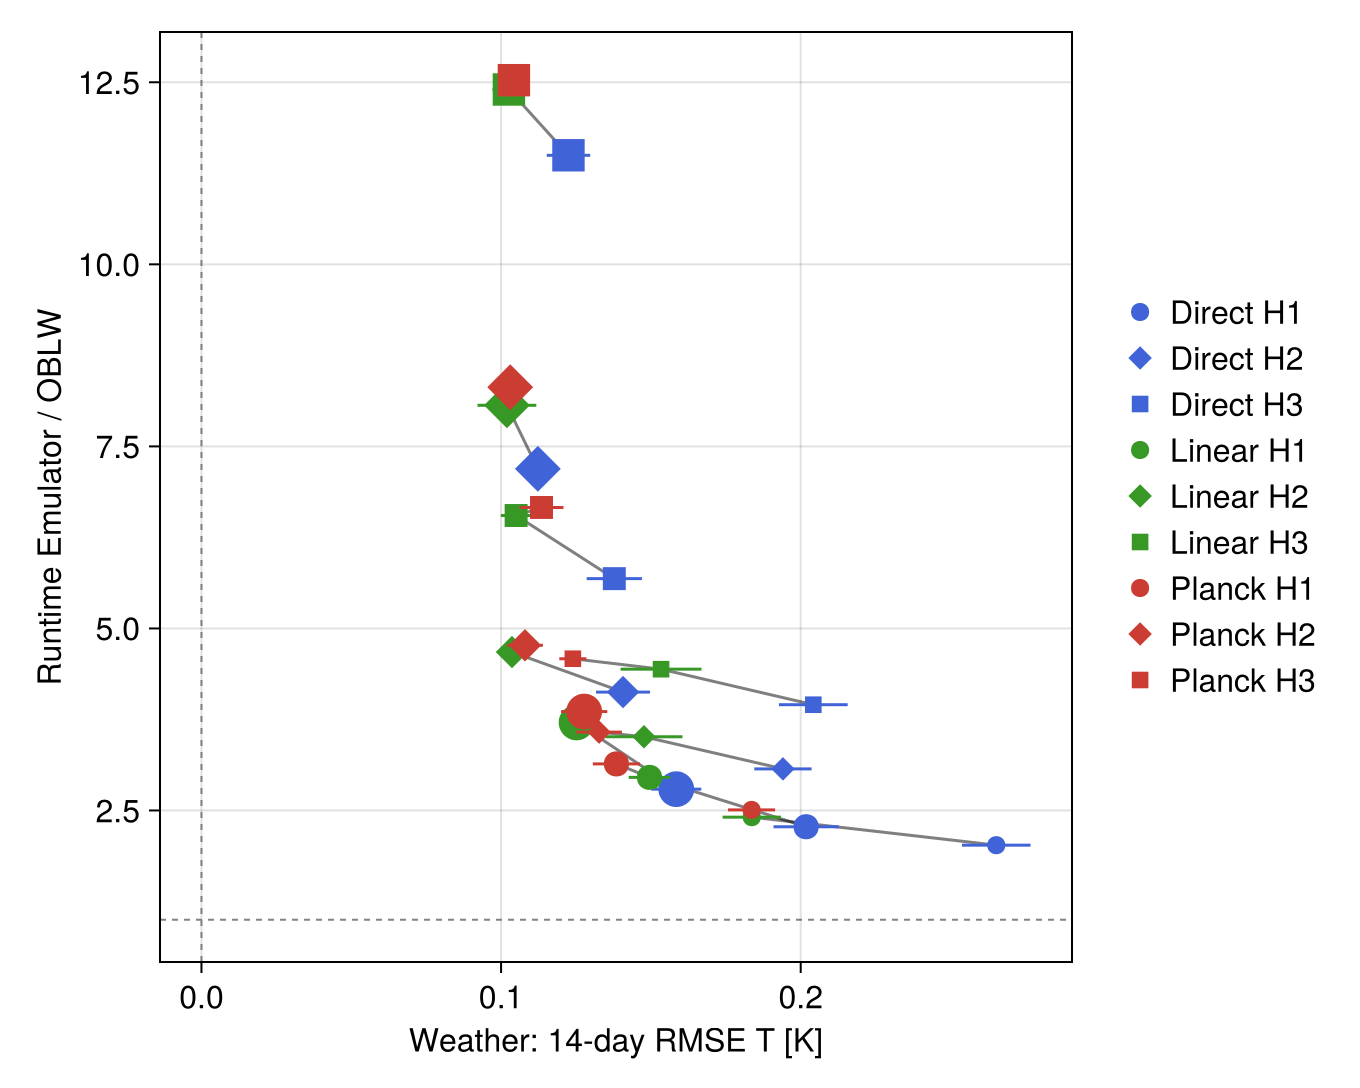

In [12]:
# Plot weather cost plane
plot_weather_cost_plane(wt, tt; looks)

In [60]:
# Define best units planck_w032_h1
best_units = ["direct_w064_h2", "linear_w064_h2", "planck_w064_h2"]

# Load weather and climate rollouts
w_best = collect_rollouts(EXP, SER, best_units, leg = :weather)
c_best = collect_rollouts(EXP, SER, best_units; leg = :climate);

## **3. Weather**

In [52]:
# Collect relevant emulators
w_em = collect_rollouts(EXP, SER, UNITS, leg=:weather);

### 3.1. Weather Growth

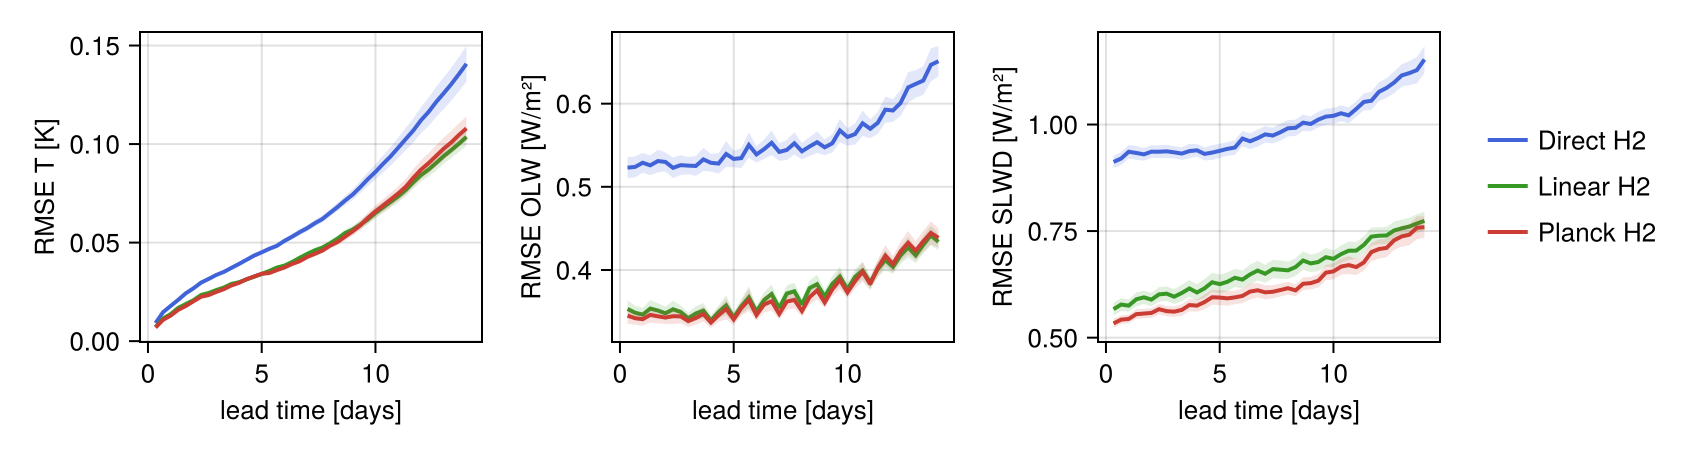

In [53]:
# Plot weather growth RMSE
plot_weather_growth(w_best, :rmse; looks)

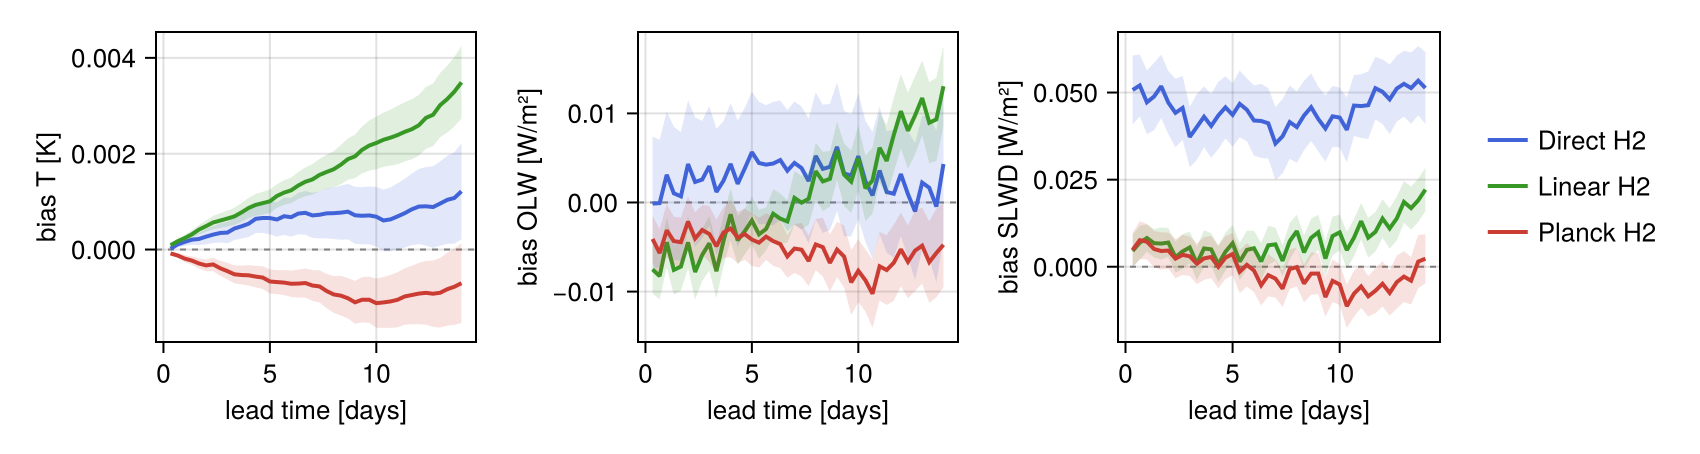

In [54]:
# Plot weather growth bias
plot_weather_growth(w_best, :bias; looks)

### 3.2. Temperature Profile

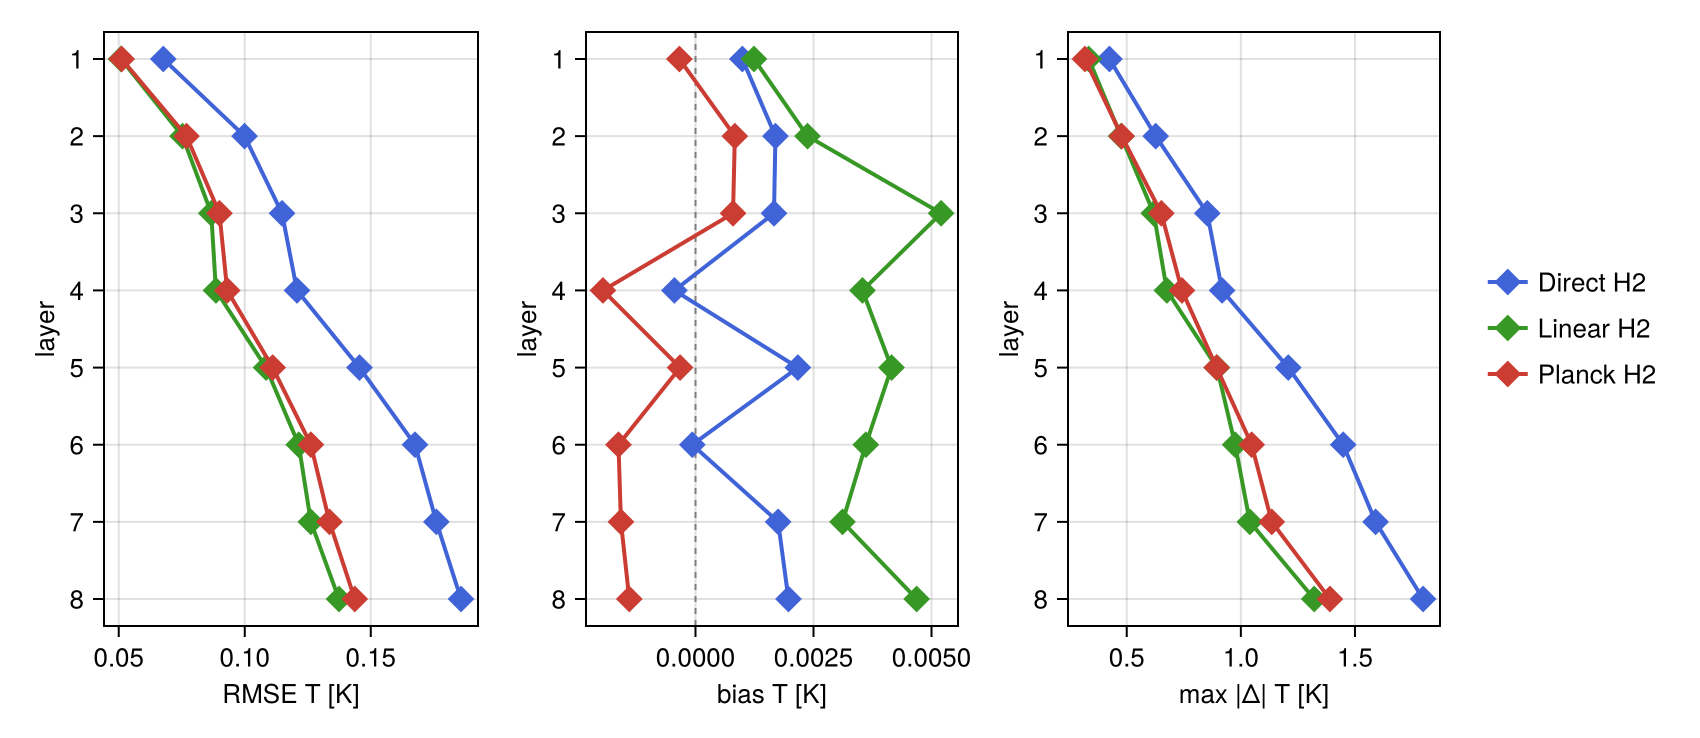

In [55]:
# Temperature profile after 14 days
plot_weather_profile(w_best, :T, 14; looks)

### 3.3. Zonal Sections

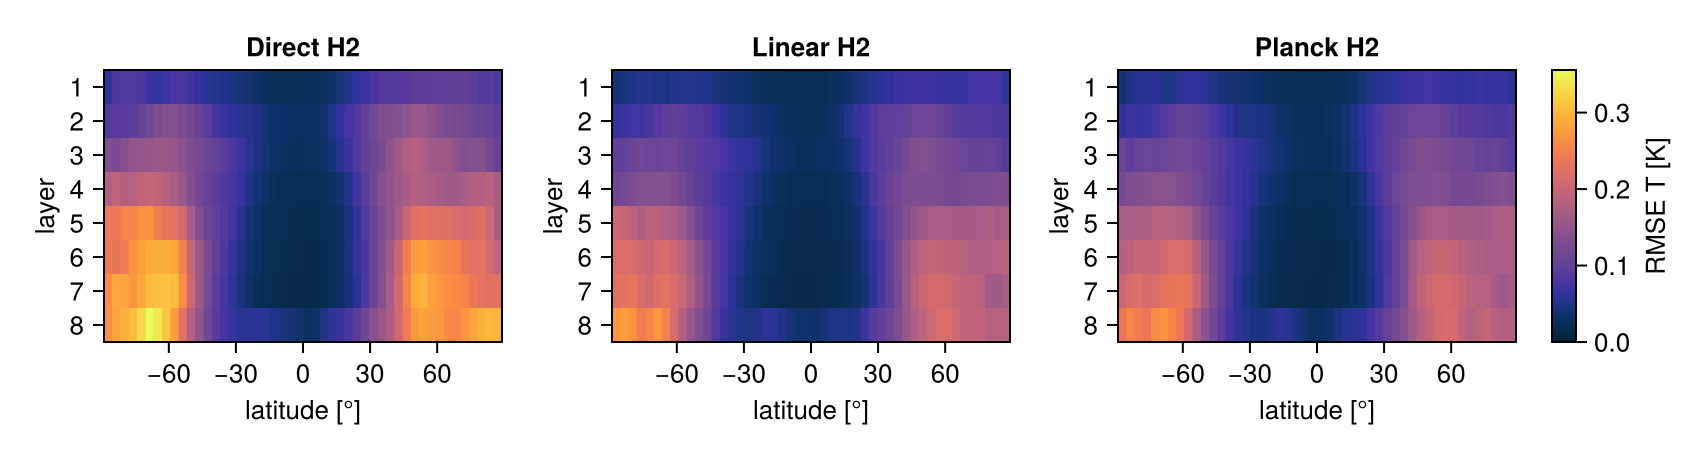

In [56]:
# Zonal temprature rmse section after 14 days
plot_weather_zonal(w_best, :T, 14, :rmse; looks)

## **4. Climate**

In [68]:
# Merge perturbed OBLW ref with best units
cf = merge((; var"0_OBLW_pert" = floor), c_best);

### 4.1. Climate Drift

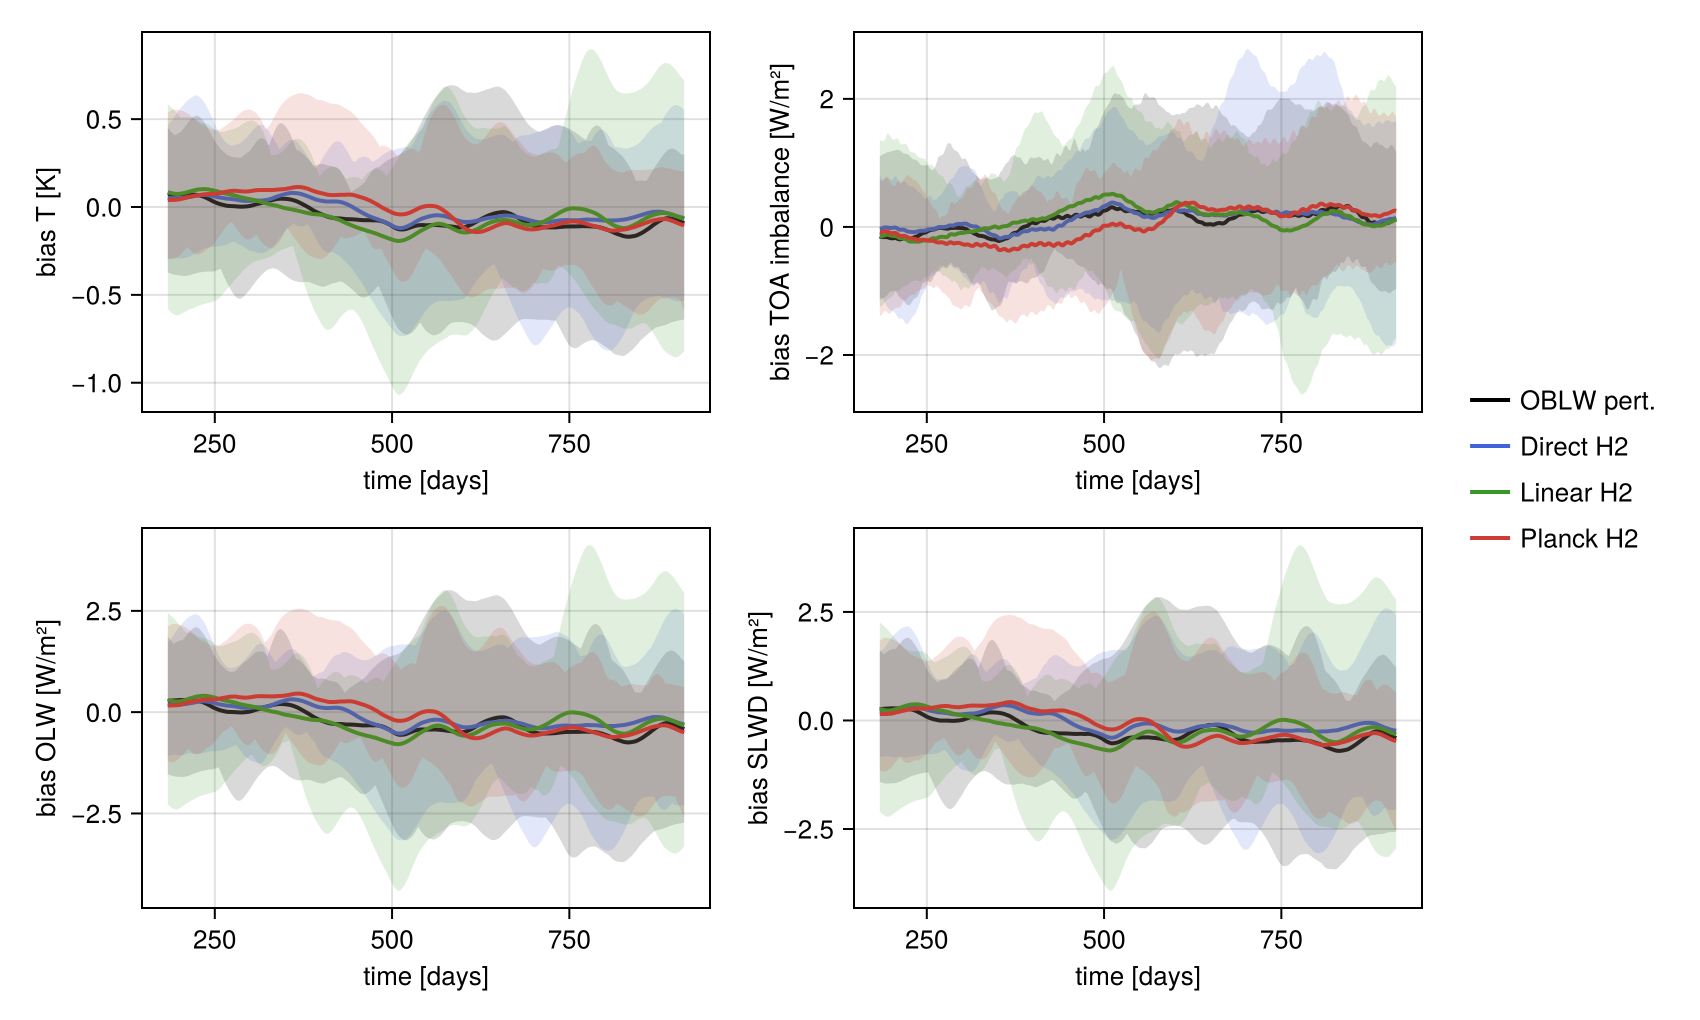

In [ ]:
# Plot drift
plot_climate_drift(cf, ref; looks, style = (;band=true))   

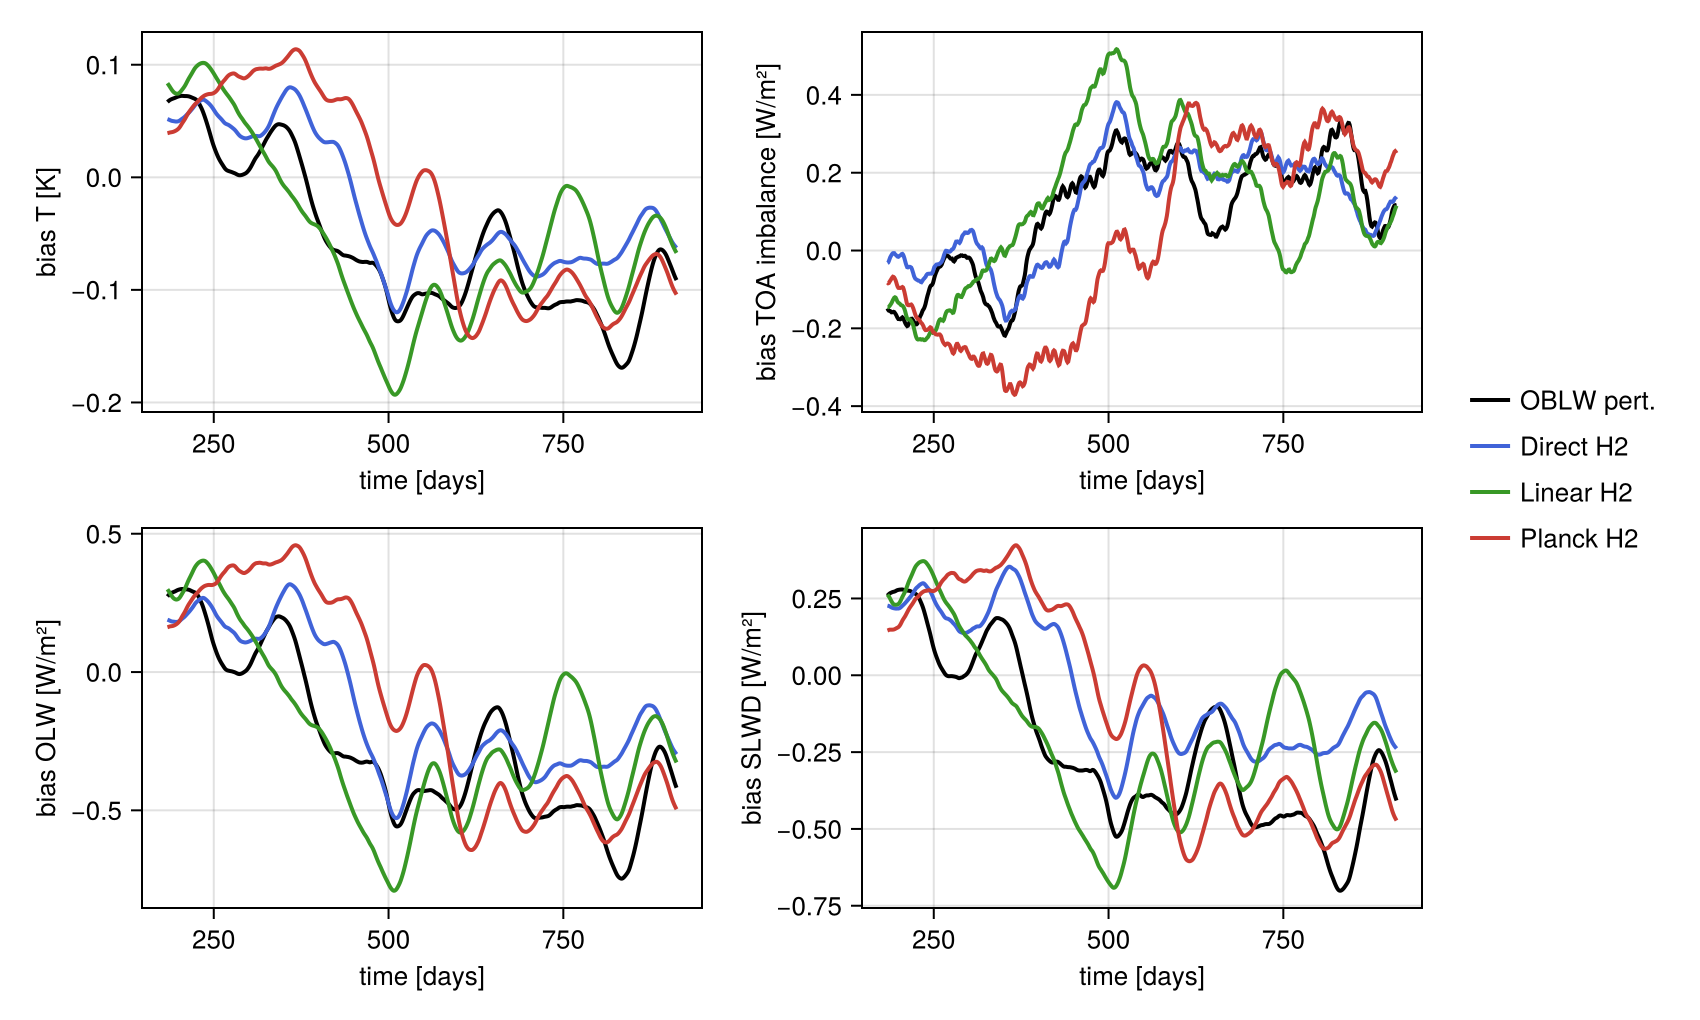

In [104]:
# Plot drift of 
plot_climate_drift(cf, ref; looks, style = (;band=false))   

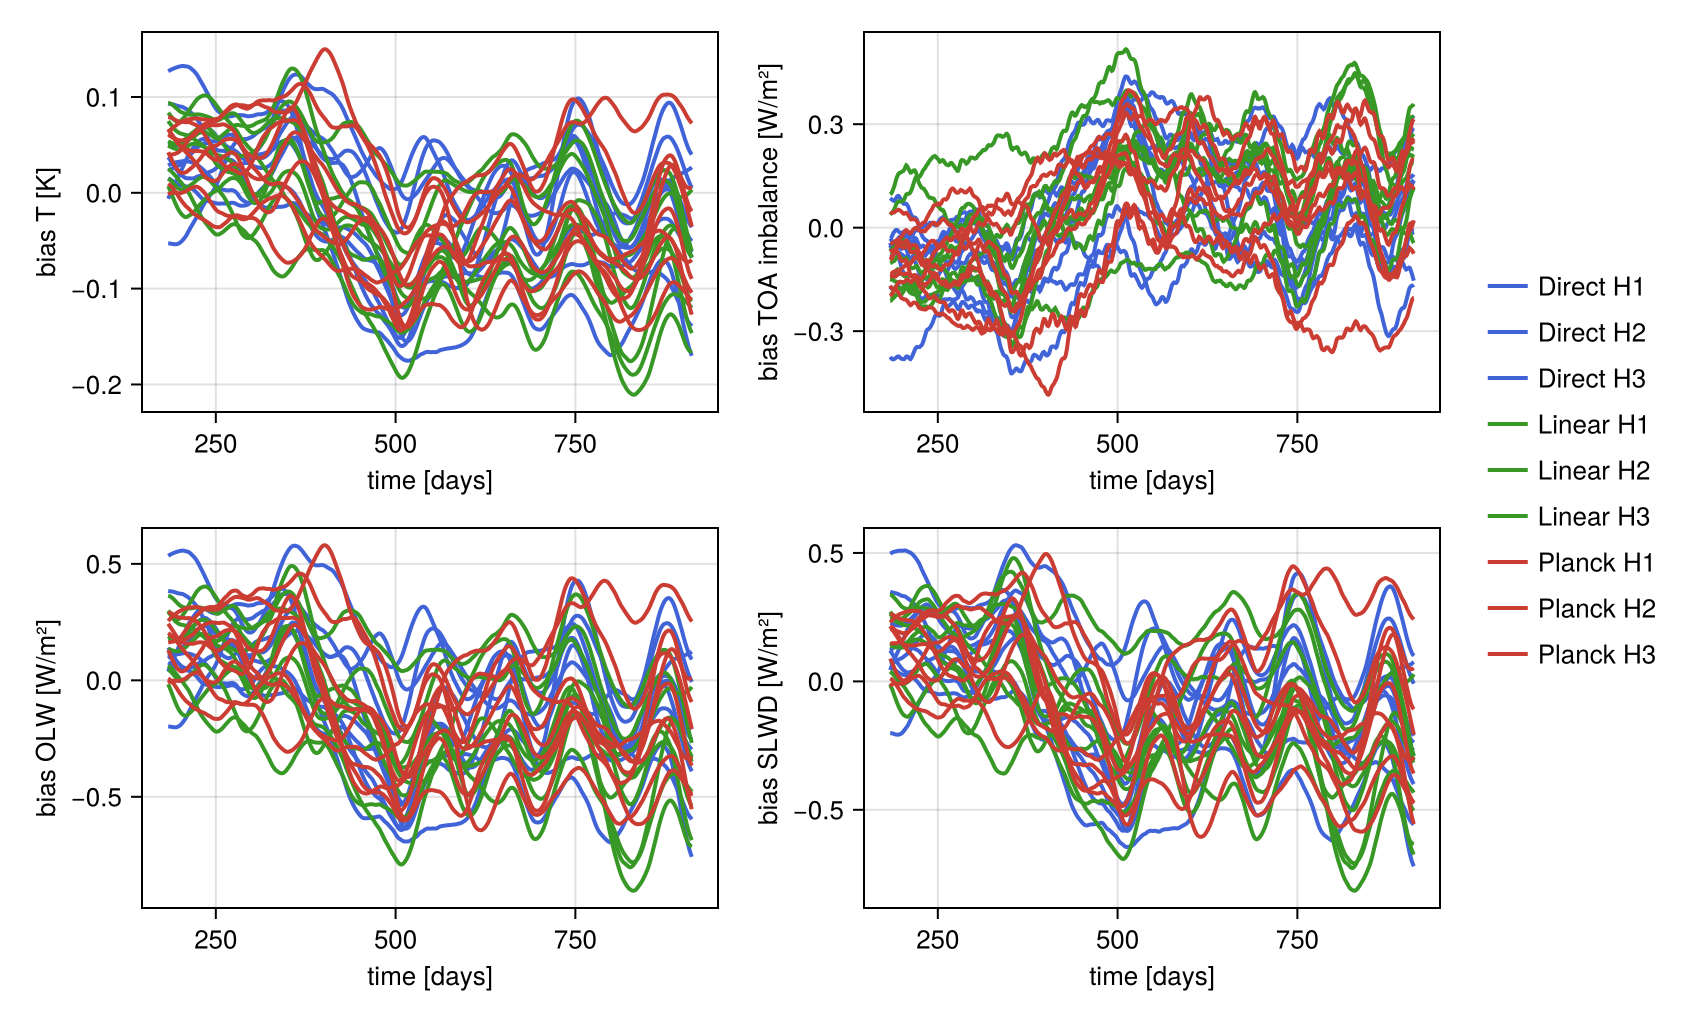

In [105]:
# Plot drift of 
plot_climate_drift(c, ref; looks, style = (;band=false))   

### 4.2. Zonal Sections

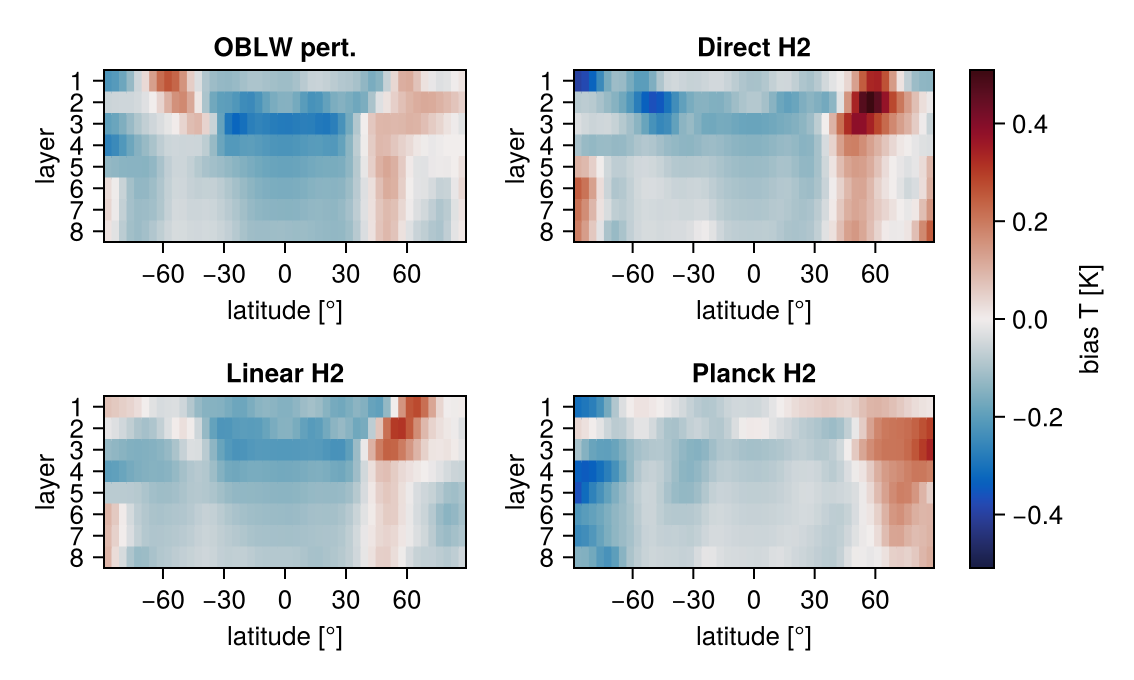

In [99]:
plot_climate_zonal(cf, ref, :T; metric = :bias, looks)  

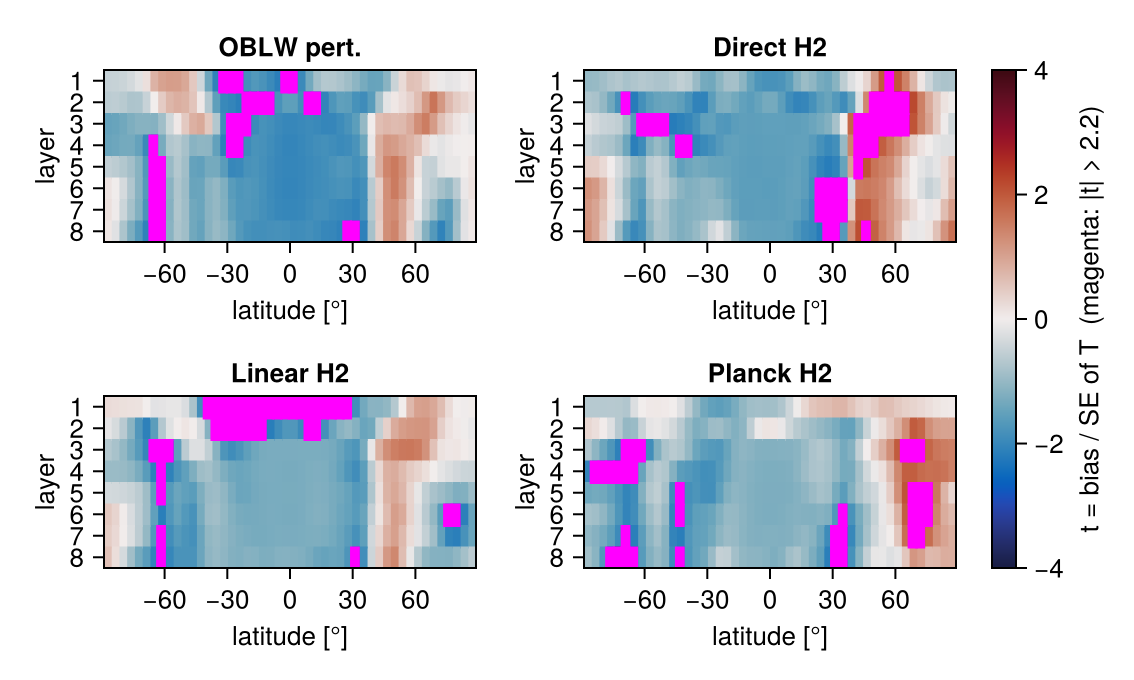

In [100]:
plot_climate_zonal(cf, ref, :T; metric = :t, looks)

### 4.3. LonLat Maps

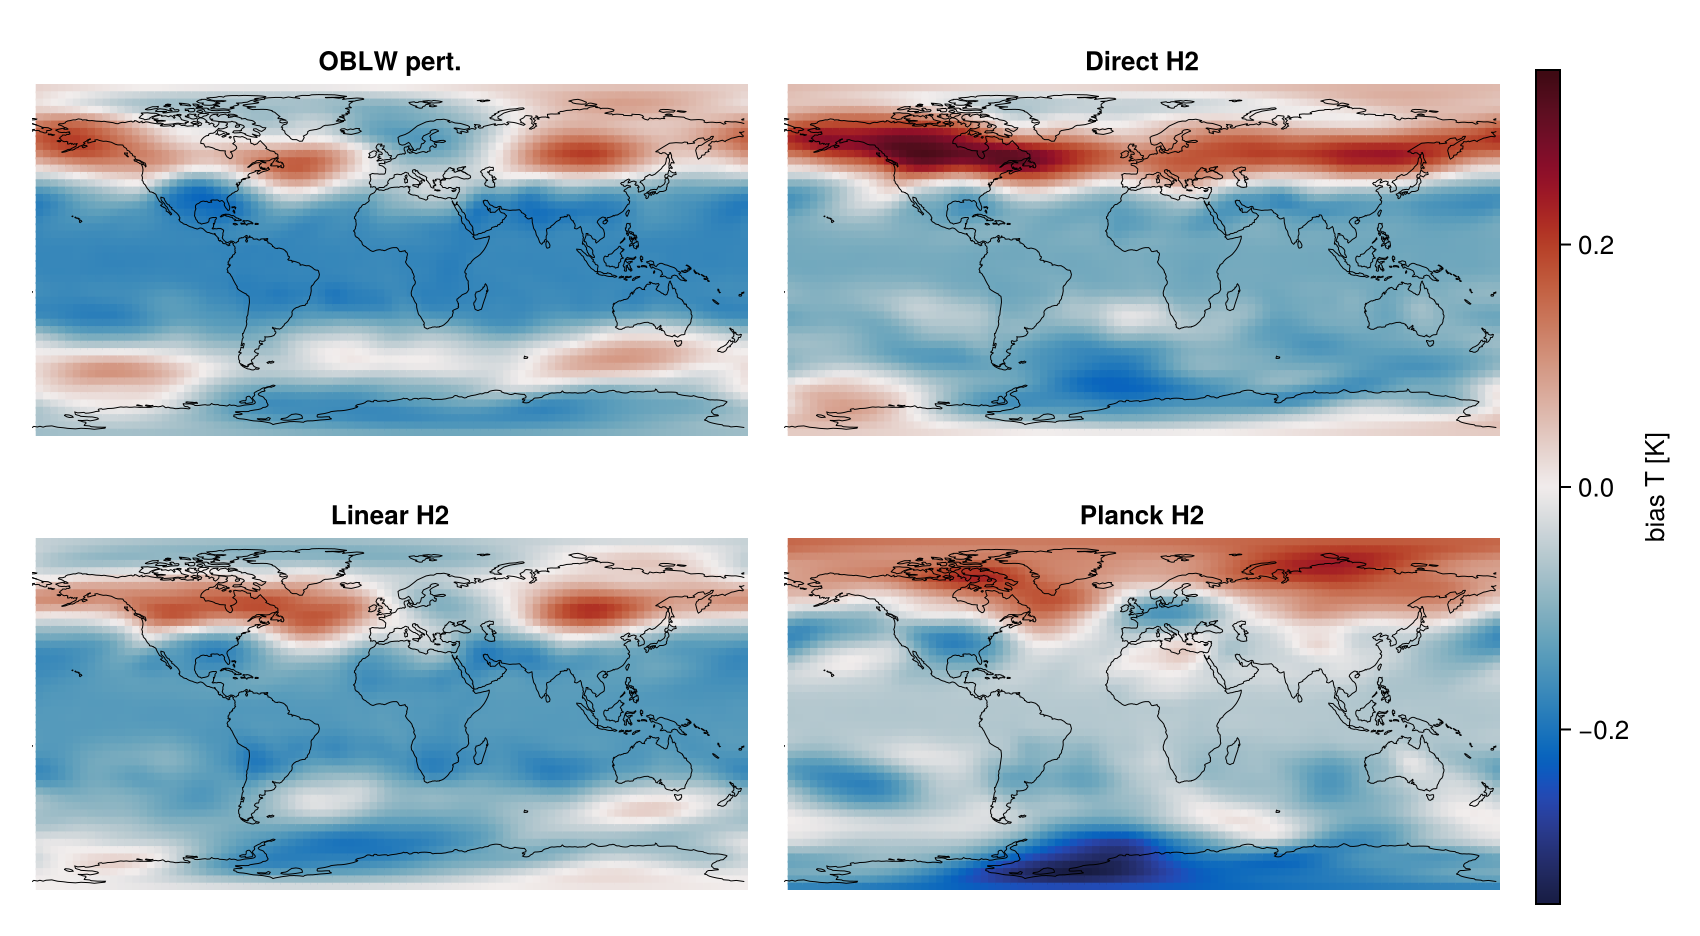

In [102]:
plot_climate_lonlat(cf, ref, :T; metric = :bias, looks) 

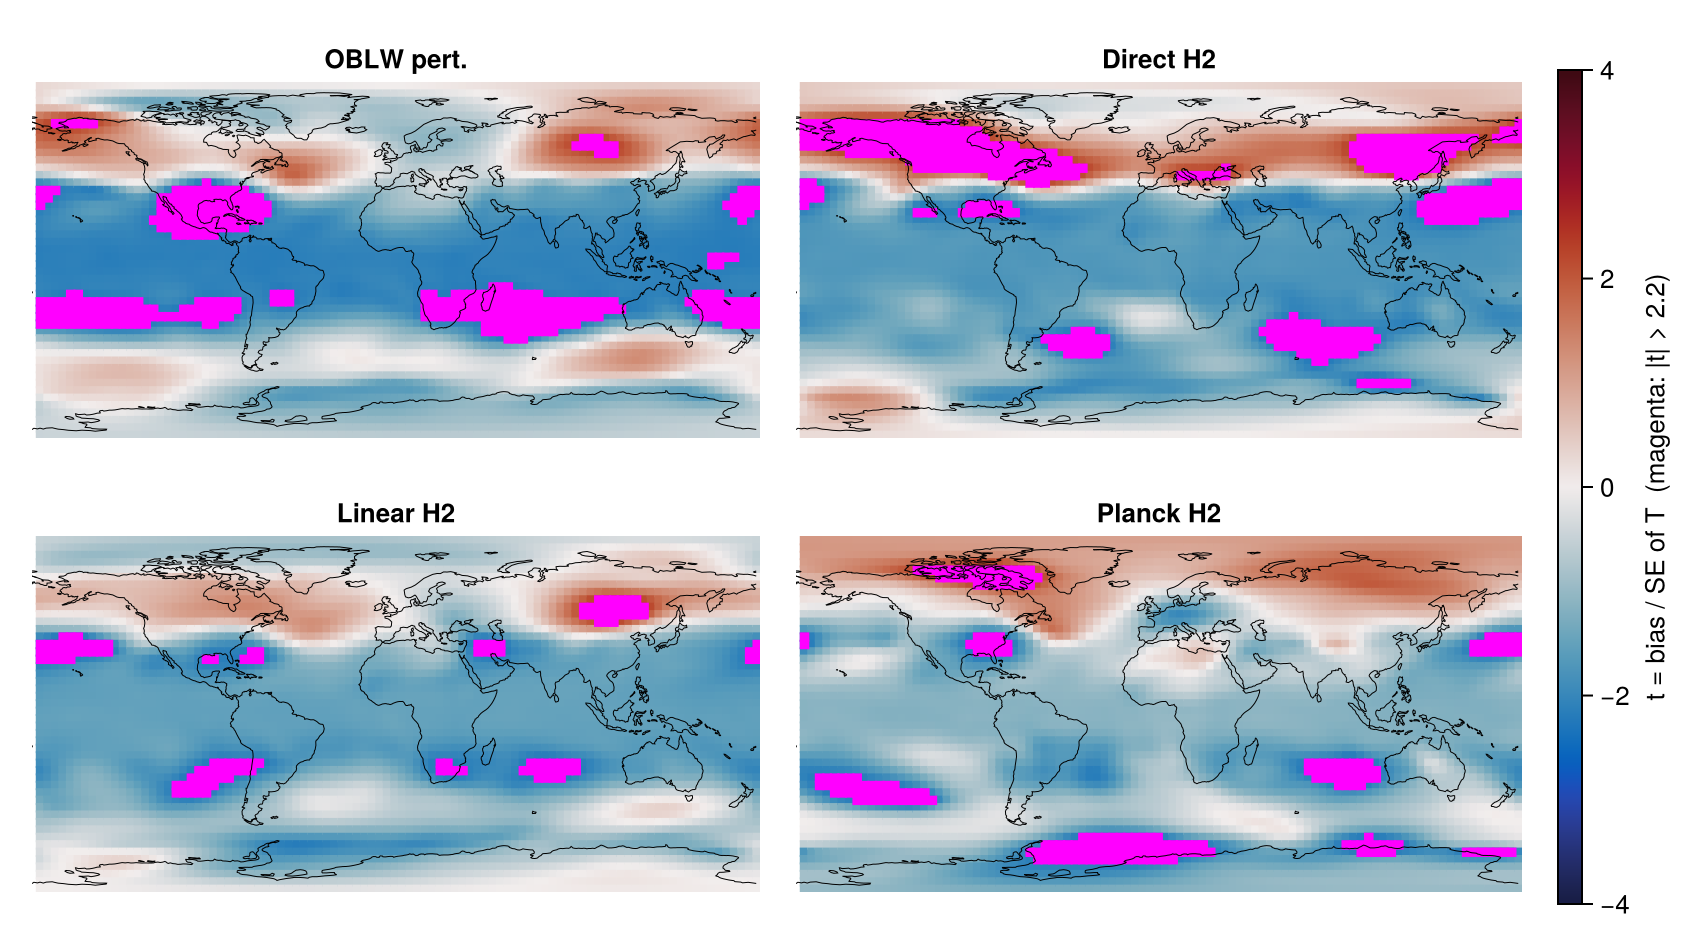

In [101]:
plot_climate_lonlat(cf, ref, :T; metric = :t, looks) 